# EIC quantum evidence: presentation lab

## Outcome
This compact lab renders accepted progress recorded by hash-bound external ledgers. Every chart is a **progress visualization**, not a final aggregate statistic. The public conclusion is **PASS_WITH_LIMITATIONS** because active coverage remains partial and the final aggregate is absent.

## Reading the record

Accepted means rows admitted only after validation. Raw ledgers are external, so the public repository alone cannot independently reproduce every count. The counts do not measure physics performance, selector accuracy, or equivalence. The active comparison stopped when no exact constituent-partition match left `max()` with no delta values, causing an unadmitted `comparison_layer_type_error`; it is not represented as 300 accepted iterations.

In [1]:
from pathlib import Path
import json
from IPython.display import SVG, display

root = Path.cwd()
if not (root / 'evidence').is_dir():
    root = root.parent
progress = json.loads((root / 'evidence' / 'campaign_progress.json').read_text(encoding='utf-8'))
for record in progress['progress_records']:
    print(f"{record['name']}: {record['accepted']}/{record['planned']} {record['status']} ({record['iteration_formula']})")
print('Final aggregate:', progress['final_aggregate']['status'])
print('Overall status:', progress['overall_status'])

shadow: 7080/7080 COMPLETE (236 frozen slots * 3 profiles * 10 seeds)
hard: 600/600 COMPLETE (10 events * 2 methods * 30 repeats)
end_to_end: 40/40 COMPLETE (10 blocks * 4 methods)
active: 56/300 PARTIAL (30 ordinals * 10 seeds)
Final aggregate: ABSENT
Overall status: PASS_WITH_LIMITATIONS


## Iteration progress

The chart below preserves the iteration semantics from the evidence schema: shadow `236 * 3 * 10`, hard `10 * 2 * 30`, end-to-end `10 * 4`, and active `30 * 10`.

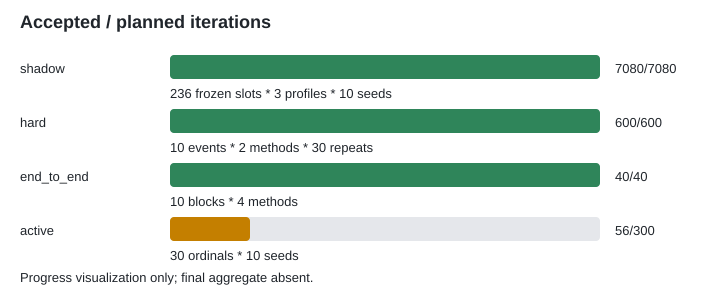

In [2]:
records = progress['progress_records']
width, left, row = 720, 170, 54
parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="290" viewBox="0 0 {width} 290">', '<style>text{font-family:Arial,sans-serif;fill:#20252b}.small{font-size:13px}.title{font-size:18px;font-weight:bold}</style>', '<text x="20" y="28" class="title">Accepted / planned iterations</text>']
for index, record in enumerate(records):
    y = 55 + index * row
    accepted = record['accepted']
    planned = record['planned']
    bar = round(430 * accepted / planned)
    color = '#2f855a' if record['status'] == 'COMPLETE' else '#c47f00'
    parts.extend([f'<text x="20" y="{y + 18}" class="small">{record["name"]}</text>', f'<rect x="{left}" y="{y}" width="430" height="24" rx="4" fill="#e5e7eb"/>', f'<rect x="{left}" y="{y}" width="{bar}" height="24" rx="4" fill="{color}"/>', f'<text x="615" y="{y + 18}" class="small">{accepted}/{planned}</text>', f'<text x="170" y="{y + 43}" class="small">{record["iteration_formula"]}</text>'])
parts.append('<text x="20" y="282" class="small">Progress visualization only; final aggregate absent.</text></svg>')
display(SVG(''.join(parts)))

## Architecture and mode semantics

```text
C++ DirectCentauro -> ordered candidate request -> local Python selector
       |                                             |
       +-- shadow: record proposal; apply classical action
       +-- active: apply only schema-valid, exact-wire-digest-bound index

C++ retains event state, distances, mutations, and output ownership. Invalid or unavailable active replies fail closed.
```

The digest binds the response to the precise UTF-8 request bytes before the JSONL delimiter. This is an interface-integrity property, not a physics result.

## Evidence boundary

| Label | Public statement |
| --- | --- |
| Hash-bound progress | accepted/planned coverage from external ledgers |
| Partial | active 56/300; failure classification recorded |
| Absent | final aggregate statistics |
| Out of scope | speedup, production readiness, universal equivalence, and non-local execution |

The snapshot date labels publication context only. It is not a verification time. Notebook execution demonstrates bundled architecture and evidence reading only; it is not protocol validation.